In [2]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import igraph as ig
import matplotlib.pyplot as plt
import networkx as nx

# Create organizational hierarchy data
data = {
    'id': ['CEO', 'Engineering', 'Product', 'Marketing', 'Sales', 'HR', 
           'Frontend', 'Backend', 'DevOps', 'Mobile', 'UI/UX', 'PM', 
           'Analytics', 'Content', 'Digital', 'Enterprise', 'SMB', 
           'Recruiting', 'Benefits', 'React', 'Angular', 'Node', 'Java', 
           'Python', 'AWS', 'Kubernetes', 'iOS', 'Android', 'Design', 
           'Research', 'PM Core', 'PM Growth', 'Web', 'Social', 'SEO', 
           'NA Sales', 'EMEA', 'APAC', 'Talent', 'University', 
           'Health', 'Retirement', 'Payroll', 'React Web', 'React Native', 
           'Node API', 'Java API', 'Data Pipelines', 'Infra', 'ML'],
    'parent': ['', 'CEO', 'CEO', 'CEO', 'CEO', 'CEO', 
               'Engineering', 'Engineering', 'Engineering', 'Engineering', 'Product', 'Product', 
               'Product', 'Marketing', 'Marketing', 'Sales', 'Sales', 
               'HR', 'HR', 'Frontend', 'Frontend', 'Backend', 'Backend', 
               'Backend', 'DevOps', 'DevOps', 'Mobile', 'Mobile', 'UI/UX', 
               'UI/UX', 'PM', 'PM', 'Digital', 'Digital', 'Digital', 
               'Enterprise', 'Enterprise', 'Enterprise', 'Recruiting', 'Recruiting', 
               'Benefits', 'Benefits', 'Benefits', 'React', 'React', 
               'Node', 'Java', 'Analytics', 'DevOps', 'Analytics'],
    'employee_count': [1, 0, 0, 0, 0, 0, 
                       0, 0, 0, 0, 0, 0, 
                       0, 0, 0, 0, 0, 
                       0, 0, 12, 8, 15, 10, 
                       7, 5, 4, 6, 5, 8, 
                       3, 4, 3, 5, 4, 2, 
                       10, 8, 6, 4, 2, 
                       3, 2, 1, 7, 5, 
                       10, 7, 4, 3, 3],
    'avg_salary': [250000, 0, 0, 0, 0, 0, 
                   0, 0, 0, 0, 0, 0, 
                   0, 0, 0, 0, 0, 
                   0, 0, 145000, 140000, 150000, 155000, 
                   160000, 165000, 170000, 135000, 130000, 120000, 
                   110000, 130000, 125000, 95000, 90000, 100000, 
                   115000, 110000, 120000, 85000, 75000, 
                   90000, 95000, 80000, 145000, 140000, 
                   150000, 155000, 160000, 165000, 175000]
}

# Calculate employee counts for non-leaf nodes
def calculate_non_leaf_counts(data):
    df = pd.DataFrame(data)
    for node in df['id']:
        children = df[df['parent'] == node]
        if len(children) > 0:
            df.loc[df['id'] == node, 'employee_count'] = children['employee_count'].sum()
    return df

org_df = calculate_non_leaf_counts(data)

### 1. Node-Link Diagram

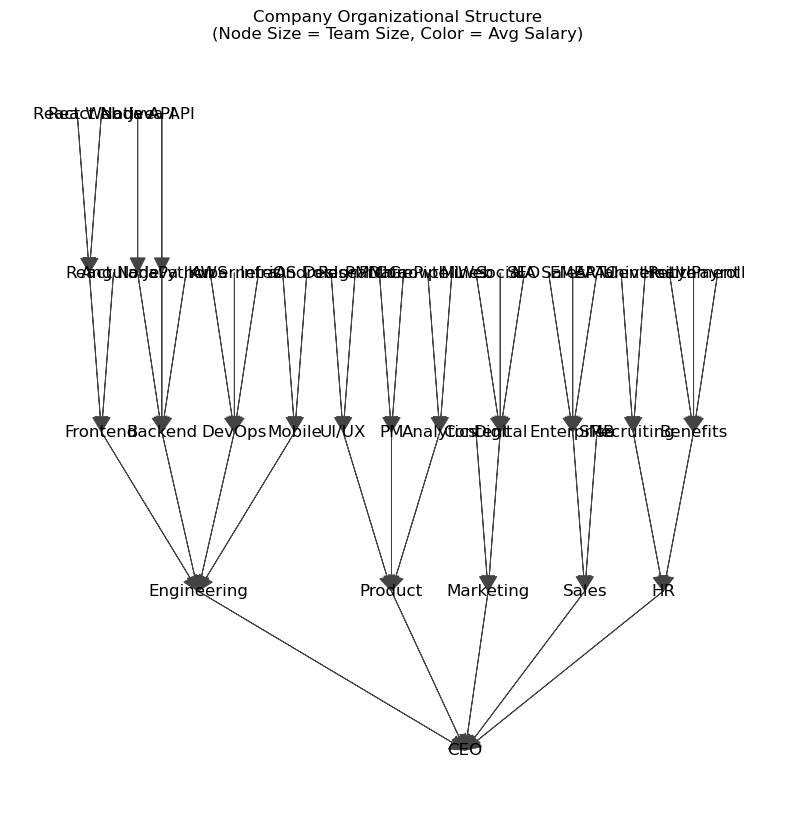

In [6]:
# Create graph from edge list
edge_list = [(i, org_df[org_df['id'] == parent].index[0]) 
             for i, parent in enumerate(org_df['parent']) 
             if parent != '']
G = ig.Graph(edges=edge_list, directed=True)

# Verify the graph has the expected number of vertices
if len(G.vs) != len(org_df):
    # Add any missing vertices (isolated nodes)
    G.add_vertices(len(org_df) - len(G.vs))

# Set visual attributes - use 'reingold_tilford' layout explicitly
layout = G.layout_reingold_tilford(mode="in", root=[0])  # Explicit root specification

visual_style = {
    "vertex_size": [size/500 for size in org_df['employee_count']],
    "vertex_color": [salary/200000 for salary in org_df['avg_salary']],
    "vertex_label": org_df['id'],
    "edge_width": 0.7,
    "layout": layout,
    "bbox": (800, 800),
    "margin": 50
}

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
ig.plot(G, target=ax, **visual_style)
ax.set_title('Company Organizational Structure\n(Node Size = Team Size, Color = Avg Salary)')
plt.show()

#### 2. Indented Tree (AST Visualization)


In [7]:
class Node:
    def __init__(self, value):
        self.value = value
        self.children = []
    
    def add_child(self, node):
        self.children.append(node)
    
    def __str__(self, level=0):
        ret = "    " * level + str(self.value) + "\n"
        for child in self.children:
            ret += child.__str__(level + 1)
        return ret

def parse_expression(expression):
    import re
    tokens = re.findall(r'(\d+|[+\-*/()])', expression)
    tokens = [t for t in tokens if t.strip()]
    return parse_terms(tokens)

def parse_terms(tokens):
    node = parse_factors(tokens)
    while tokens and tokens[0] in '+-':
        op = tokens.pop(0)
        new_node = Node(op)
        new_node.add_child(node)
        new_node.add_child(parse_factors(tokens))
        node = new_node
    return node

def parse_factors(tokens):
    node = parse_value(tokens)
    while tokens and tokens[0] in '*/':
        op = tokens.pop(0)
        new_node = Node(op)
        new_node.add_child(node)
        new_node.add_child(parse_value(tokens))
        node = new_node
    return node

def parse_value(tokens):
    if tokens[0] == '(':
        tokens.pop(0)
        node = parse_terms(tokens)
        tokens.pop(0)  # Remove ')'
        return node
    else:
        return Node(tokens.pop(0))

expression = "(1 + 2) - 3 * (7 / 4 + (5 - 7))"
ast = parse_expression(expression)

print("AST for expression: (1 + 2) - 3 * (7 / 4 + (5 - 7))")
print(ast)

AST for expression: (1 + 2) - 3 * (7 / 4 + (5 - 7))
-
    +
        1
        2
    *
        3
        +
            /
                7
                4
            -
                5
                7



### Tree map

In [10]:
# Option 1: Filter out rows with zero employee_count
org_df_filtered = org_df[org_df['employee_count'] > 0]

fig = px.treemap(org_df_filtered, 
                 path=['parent', 'id'], 
                 values='employee_count',
                 color='avg_salary',
                 color_continuous_scale='Viridis',
                 title='Company Organization Treemap (Size = Team Size, Color = Avg Salary)',
                 hover_data=['avg_salary'])
fig.update_traces(textinfo="label+value")
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()